[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Red1-Rahman/NiriZan/blob/main/experiments/04_regression_detection_ci_gate.ipynb)
[![Run in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/Red1-Rahman/NiriZan/blob/main/experiments/04_regression_detection_ci_gate.ipynb)

# 04 — Statistical Regression Detection & Deployment Gate

## Goal
Validate the complete statistical regression detection pipeline and deployment gate before locking down production extractions in `src/nirizan/`.

**Core Question Answered**:
Given historical baseline runs ($A \dots E$) and a newly evaluated candidate run, can NiriZan mathematically prove whether quality has genuinely regressed, quantify statistical confidence, assign actionable severity levels, and issue an automated deployment decision (`PASS` / `FAIL`)?

In [1]:
import math
import random
from dataclasses import dataclass, field
from datetime import datetime, timezone
from enum import Enum
from typing import Any, Dict, List, Optional, Tuple
from uuid import UUID, uuid4

import matplotlib.pyplot as plt
import numpy as np

# Seed for reproducible experiments
random.seed(42)
np.random.seed(42)

print("Phase 4 experimentation environment initialized.")

Phase 4 experimentation environment initialized.


## Section 1 — Motivation: Why Point Estimates Fail

Consider two evaluated evaluation runs:
* Historical Baseline Groundedness = `0.89`
* Candidate Model Groundedness = `0.86`

**Is a 0.03 drop a genuine regression or natural stochastic variance?**

In LLM systems, prompt variations, temperature sampling, and evaluator jitter generate variance. Comparing raw point estimates leads to two failure modes:
1. **False Alarms (Flaky CI)**: Rejecting pull requests due to random sampling noise when real performance is unchanged.
2. **Silent Degradation**: Missing real 2% cumulative regressions across consecutive releases because each drop is under an arbitrary static threshold.

**Required Solution**: NiriZan must treat metrics as sample distributions and apply statistical hypothesis testing ($z$-scores, Welch's $t$-tests, confidence intervals) to prove regression before blocking deployment.

## Section 2 — Building the Historical Baseline

We construct 5 historical baseline evaluation runs ($Run\ A \dots Run\ E$). Each run contains evaluations across three core metrics: `context_relevance`, `groundedness`, and `answer_relevance`.

In [2]:
@dataclass(frozen=True)
class EvaluationMetric:
    name: str
    scores: List[float]

@dataclass(frozen=True)
class EvaluationRun:
    run_id: UUID
    commit_sha: str
    metrics: Dict[str, EvaluationMetric]
    timestamp: datetime = field(default_factory=lambda: datetime.now(timezone.utc))

# Simulate 5 historical baseline runs with natural sample variance
def generate_baseline_runs() -> List[EvaluationRun]:
    baseline_runs = []
    commits = ["a1b2c3d", "e4f5g6h", "7i8j9k0", "l1m2n3o", "p4q5r6s"]

    # Underlying true means & standard deviations for baseline
    metric_params = {
        "context_relevance": (0.85, 0.03),
        "groundedness": (0.89, 0.02),
        "answer_relevance": (0.92, 0.025)
    }

    for commit in commits:
        run_metrics = {}
        for m_name, (mean, std) in metric_params.items():
            # 30 query evaluation samples per run
            scores = np.clip(np.random.normal(mean, std, 30), 0.0, 1.0).tolist()
            run_metrics[m_name] = EvaluationMetric(name=m_name, scores=scores)

        baseline_runs.append(
            EvaluationRun(run_id=uuid4(), commit_sha=commit, metrics=run_metrics)
        )
    return baseline_runs

baseline_runs = generate_baseline_runs()

# Aggregate metrics across baseline runs
def aggregate_baseline_stats(runs: List[EvaluationRun]) -> Dict[str, Dict[str, float]]:
    aggregated = {}
    all_metrics = {m for run in runs for m in run.metrics.keys()}

    for m_name in all_metrics:
        all_scores = []
        for run in runs:
            if m_name in run.metrics:
                all_scores.extend(run.metrics[m_name].scores)

        arr = np.array(all_scores)
        n = len(arr)
        mean = float(np.mean(arr))
        var = float(np.var(arr, ddof=1)) if n > 1 else 0.0
        std = float(np.std(arr, ddof=1)) if n > 1 else 0.0

        aggregated[m_name] = {"mean": mean, "variance": var, "std_dev": std, "sample_size": n}
        print(f"Baseline Metric: {m_name:<20} | Mean: {mean:.4f} | StdDev: {std:.4f} | Samples: {n}")
    return aggregated

baseline_stats = aggregate_baseline_stats(baseline_runs)

Baseline Metric: groundedness         | Mean: 0.8906 | StdDev: 0.0191 | Samples: 150
Baseline Metric: answer_relevance     | Mean: 0.9194 | StdDev: 0.0252 | Samples: 150
Baseline Metric: context_relevance    | Mean: 0.8512 | StdDev: 0.0286 | Samples: 150


## Section 3 — Evaluating Regression Algorithms

We prototype and evaluate four regression detection algorithms on candidate runs:
1. **Absolute Threshold Drop**: $\Delta = \bar{X}_{cand} - \bar{X}_{base} < -0.05$
2. **Z-Score Standard Deviation Test**: $z = \frac{\bar{X}_{cand} - \bar{X}_{base}}{\sigma_{base} / \sqrt{N_{cand}}}$
3. **Welch's Two-Sample t-Test Confidence Interval**: Unpooled variance test accounting for sample size and unequal variance.
4. **Bootstrap Resampling**: Non-parametric percentile estimation for non-normal score distributions.

In [3]:
def eval_absolute_drop(cand_scores: List[float], base_stats: Dict[str, float], threshold: float = 0.05) -> Tuple[bool, float]:
    cand_mean = float(np.mean(cand_scores))
    delta = cand_mean - base_stats["mean"]
    is_regression = delta < -threshold
    return is_regression, delta

def eval_z_score(cand_scores: List[float], base_stats: Dict[str, float], z_limit: float = -1.96) -> Tuple[bool, float]:
    cand_mean = float(np.mean(cand_scores))
    cand_n = len(cand_scores)
    se = base_stats["std_dev"] / math.sqrt(cand_n) if cand_n > 0 and base_stats["std_dev"] > 0 else 1e-6
    z = (cand_mean - base_stats["mean"]) / se
    return z < z_limit, z

def eval_welch_t_test(cand_scores: List[float], base_scores: List[float], alpha: float = 0.05) -> Tuple[bool, float]:
    c_arr, b_arr = np.array(cand_scores), np.array(base_scores)
    c_mean, b_mean = np.mean(c_arr), np.mean(b_arr)
    c_var, b_var = np.var(c_arr, ddof=1), np.var(b_arr, ddof=1)
    c_n, b_n = len(c_arr), len(b_arr)

    se_diff = math.sqrt((c_var / c_n) + (b_var / b_n))
    t_stat = (c_mean - b_mean) / se_diff if se_diff > 0 else 0.0
    # Welch-Satterthwaite degrees of freedom approximation
    df = ((c_var/c_n + b_var/b_n)**2) / (((c_var/c_n)**2)/(c_n-1) + ((b_var/b_n)**2)/(b_n-1)) if se_diff > 0 else 1

    # Critical t-value for 1-tailed test (regression)
    is_regression = t_stat < -1.68  # approx critical value for alpha=0.05
    return is_regression, t_stat

def eval_bootstrap_ci(cand_scores: List[float], base_scores: List[float], num_bootstraps: int = 1000) -> Tuple[bool, Tuple[float, float]]:
    deltas = []
    c_arr, b_arr = np.array(cand_scores), np.array(base_scores)
    for _ in range(num_bootstraps):
        c_sample = np.random.choice(c_arr, size=len(c_arr), replace=True)
        b_sample = np.random.choice(b_arr, size=len(b_arr), replace=True)
        deltas.append(np.mean(c_sample) - np.mean(b_sample))

    ci_lower = float(np.percentile(deltas, 2.5))
    ci_upper = float(np.percentile(deltas, 97.5))
    # Regression if upper bound of delta CI is below 0
    return ci_upper < 0.0, (ci_lower, ci_upper)

# Test comparison algorithms on a simulated 0.03 drop candidate run
cand_scores_test = np.clip(np.random.normal(0.86, 0.02, 30), 0.0, 1.0).tolist()
base_all_scores = [s for r in baseline_runs for s in r.metrics["groundedness"].scores]

print("Algorithm Benchmark (Groundedness Drop from 0.89 to 0.86):")
print("  Absolute Drop (>0.05):", eval_absolute_drop(cand_scores_test, baseline_stats["groundedness"]))
print("  Z-Score (Limit -1.96):", eval_z_score(cand_scores_test, baseline_stats["groundedness"]))
print("  Welch t-Test (Alpha 0.05):", eval_welch_t_test(cand_scores_test, base_all_scores))
print("  Bootstrap 95% CI Delta:", eval_bootstrap_ci(cand_scores_test, base_all_scores))

Algorithm Benchmark (Groundedness Drop from 0.89 to 0.86):
  Absolute Drop (>0.05): (False, -0.029638881145784057)
  Z-Score (Limit -1.96): (True, -8.477643805987523)
  Welch t-Test (Alpha 0.05): (np.True_, np.float64(-6.858432887753933))
  Bootstrap 95% CI Delta: (True, (-0.03788950175420386, -0.021069987865672348))


## Section 4 — Comparator Prototype

We prototype `BaselineComparator`, producing a `RegressionVerdict` data contract for every metric evaluated.

In [4]:
class SeverityLevel(str, Enum):
    NONE = "NONE"
    WARNING = "WARNING"
    BLOCKING = "BLOCKING"

@dataclass(frozen=True)
class MetricRegressionVerdict:
    metric_name: str
    candidate_mean: float
    baseline_mean: float
    delta: float
    z_score: float
    confidence_lower: float
    confidence_upper: float
    statistically_significant: bool
    severity: SeverityLevel
    reason: str

class BaselineComparator:
    def __init__(self, z_warning: float = -1.645, z_blocking: float = -2.326, absolute_drop_limit: float = 0.03):
        self.z_warning = z_warning      # p < 0.05 1-tailed
        self.z_blocking = z_blocking    # p < 0.01 1-tailed
        self.absolute_drop_limit = absolute_drop_limit

    def compare_metric(
        self,
        metric_name: str,
        cand_scores: List[float],
        base_runs: List[EvaluationRun]
    ) -> MetricRegressionVerdict:
        # Extract baseline scores for this metric
        base_scores = []
        for r in base_runs:
            if metric_name in r.metrics:
                base_scores.extend(r.metrics[metric_name].scores)

        if not cand_scores or not base_scores:
            return MetricRegressionVerdict(
                metric_name=metric_name, candidate_mean=np.mean(cand_scores) if cand_scores else 0.0,
                baseline_mean=np.mean(base_scores) if base_scores else 0.0,
                delta=0.0, z_score=0.0, confidence_lower=0.0, confidence_upper=0.0,
                statistically_significant=False, severity=SeverityLevel.NONE,
                reason="Insufficient data for evaluation"
            )

        cand_mean, base_mean = float(np.mean(cand_scores)), float(np.mean(base_scores))
        cand_n, base_n = len(cand_scores), len(base_scores)
        delta = cand_mean - base_mean

        # Standard error calculation
        c_var = float(np.var(cand_scores, ddof=1)) if cand_n > 1 else 0.0
        b_var = float(np.var(base_scores, ddof=1)) if base_n > 1 else 0.0
        se_diff = math.sqrt((c_var / cand_n) + (b_var / base_n))

        z_score = delta / se_diff if se_diff > 1e-6 else 0.0
        ci_lower = delta - (1.96 * se_diff)
        ci_upper = delta + (1.96 * se_diff)

        stat_sig = z_score < self.z_warning

        # Determine Severity
        if z_score < self.z_blocking or delta < -self.absolute_drop_limit * 2:
            severity = SeverityLevel.BLOCKING
            reason = f"Severe regression: Z-score ({z_score:.2f}) < {self.z_blocking} or drop ({delta:.4f}) double limit."
        elif z_score < self.z_warning or delta < -self.absolute_drop_limit:
            severity = SeverityLevel.WARNING
            reason = f"Moderate regression: Z-score ({z_score:.2f}) < {self.z_warning} or drop ({delta:.4f}) exceeds limit."
        else:
            severity = SeverityLevel.NONE
            reason = "Metric within acceptable statistical bounds."

        return MetricRegressionVerdict(
            metric_name=metric_name, candidate_mean=cand_mean, baseline_mean=base_mean,
            delta=delta, z_score=z_score, confidence_lower=ci_lower, confidence_upper=ci_upper,
            statistically_significant=stat_sig, severity=severity, reason=reason
        )

## Section 5 — Severity Classification Experiments

We test the `BaselineComparator` across three candidate scenarios:
1. **Scenario 1 (Normal Variance)**: Groundedness mean = 0.885 (No regression)
2. **Scenario 2 (Minor Drift)**: Groundedness mean = 0.865 (WARNING severity)
3. **Scenario 3 (Major Degradation)**: Groundedness mean = 0.780 (BLOCKING severity)

In [5]:
comparator = BaselineComparator()

scenarios = {
    "Normal Variance": 0.885,
    "Minor Drift": 0.865,
    "Major Degradation": 0.780
}

for name, target_mean in scenarios.items():
    scores = np.clip(np.random.normal(target_mean, 0.02, 30), 0.0, 1.0).tolist()
    verdict = comparator.compare_metric("groundedness", scores, baseline_runs)
    print(f"Scenario [{name:<18}]: Severity = {verdict.severity.value:<8} | Delta = {verdict.delta:.4f} | Z = {verdict.z_score:.2f}")
    print(f"  Reason: {verdict.reason}")

Scenario [Normal Variance   ]: Severity = NONE     | Delta = 0.0004 | Z = 0.10
  Reason: Metric within acceptable statistical bounds.
Scenario [Minor Drift       ]: Severity = BLOCKING | Delta = -0.0280 | Z = -8.49
  Reason: Severe regression: Z-score (-8.49) < -2.326 or drop (-0.0280) double limit.
Scenario [Major Degradation ]: Severity = BLOCKING | Delta = -0.1080 | Z = -25.64
  Reason: Severe regression: Z-score (-25.64) < -2.326 or drop (-0.1080) double limit.


## Section 6 — Gate Prototype & CI Simulation

We construct `DeploymentGate`, aggregating all `MetricRegressionVerdict` signals into a final `GateVerdict`. We then simulate a CI pipeline runner.

In [6]:
@dataclass(frozen=True)
class GateVerdict:
    passed: bool
    candidate_run_id: UUID
    verdicts: List[MetricRegressionVerdict]
    highest_severity: SeverityLevel
    evaluated_at: datetime = field(default_factory=lambda: datetime.now(timezone.utc))

class DeploymentGate:
    def __init__(self, block_on_warning: bool = False):
        self.block_on_warning = block_on_warning

    def evaluate(self, candidate_run_id: UUID, verdicts: List[MetricRegressionVerdict]) -> GateVerdict:
        has_blocking = any(v.severity == SeverityLevel.BLOCKING for v in verdicts)
        has_warning = any(v.severity == SeverityLevel.WARNING for v in verdicts)

        if has_blocking:
            highest = SeverityLevel.BLOCKING
        elif has_warning:
            highest = SeverityLevel.WARNING
        else:
            highest = SeverityLevel.NONE

        passed = not has_blocking if not self.block_on_warning else (highest == SeverityLevel.NONE)

        return GateVerdict(
            passed=passed,
            candidate_run_id=candidate_run_id,
            verdicts=verdicts,
            highest_severity=highest
        )

# CI Pipeline Simulation Function
def simulate_ci_pipeline(candidate_run: EvaluationRun, baseline: List[EvaluationRun]) -> int:
    comp = BaselineComparator()
    gate = DeploymentGate()

    metric_verdicts = []
    for m_name, m_data in candidate_run.metrics.items():
        verdict = comp.compare_metric(m_name, m_data.scores, baseline)
        metric_verdicts.append(verdict)

    gate_verdict = gate.evaluate(candidate_run.run_id, metric_verdicts)

    print("\n=== SIMULATED GITHUB ACTIONS RUN ===")
    print(f"Candidate Run ID: {gate_verdict.candidate_run_id}")
    print(f"Highest Severity: {gate_verdict.highest_severity.value}")
    for v in gate_verdict.verdicts:
        status_mark = "[FAIL]" if v.severity == SeverityLevel.BLOCKING else ("[WARN]" if v.severity == SeverityLevel.WARNING else "[PASS]")
        print(f"  {status_mark} {v.metric_name:<20}: delta={v.delta:+.4f}, z={v.z_score:.2f} ({v.severity.value})")

    if gate_verdict.passed:
        print("Pipeline Status: SUCCESS (Exit Code 0)")
        return 0
    else:
        print("Pipeline Status: DEPLOYMENT BLOCKED (Exit Code 1)")
        return 1

# Test CI simulation on regressed run
bad_cand_metrics = {
    "context_relevance": EvaluationMetric("context_relevance", np.random.normal(0.85, 0.02, 30).tolist()),
    "groundedness": EvaluationMetric("groundedness", np.random.normal(0.72, 0.03, 30).tolist()), # Severe drop
    "answer_relevance": EvaluationMetric("answer_relevance", np.random.normal(0.91, 0.02, 30).tolist())
}
bad_cand_run = EvaluationRun(run_id=uuid4(), commit_sha="badcommit123", metrics=bad_cand_metrics)
exit_code = simulate_ci_pipeline(bad_cand_run, baseline_runs)
assert exit_code == 1, "Gate failed to block regressed release!"


=== SIMULATED GITHUB ACTIONS RUN ===
Candidate Run ID: b6701ff4-99bd-4c1c-b782-88804fc50d8c
Highest Severity: BLOCKING
  [PASS] context_relevance   : delta=+0.0011, z=0.22 (NONE)
  [FAIL] groundedness        : delta=-0.1686, z=-26.54 (BLOCKING)
  [FAIL] answer_relevance    : delta=-0.0091, z=-2.49 (BLOCKING)
Pipeline Status: DEPLOYMENT BLOCKED (Exit Code 1)


## Section 7 — Robustness & Edge Cases

We stress-test the `BaselineComparator` against key real-world edge cases:
1. Empty baseline dataset
2. Single historical run
3. Missing metrics in candidate or baseline
4. Newly introduced metric
5. NaNs or extreme outlier noise
6. Zero variance across samples

In [7]:
comp = BaselineComparator()

print("--- Edge Case Tests ---")

# 1. Empty Baseline
v1 = comp.compare_metric("groundedness", [0.88, 0.89], [])
print(f"1. Empty Baseline      -> Severity: {v1.severity.value:<8} | Reason: {v1.reason}")

# 2. Single Historical Run
single_run = [baseline_runs[0]]
v2 = comp.compare_metric("groundedness", [0.88, 0.89], single_run)
print(f"2. Single Run Baseline -> Severity: {v2.severity.value:<8} | Z-Score: {v2.z_score:.2f}")

# 3. Newly Introduced Metric (Not in baseline)
v3 = comp.compare_metric("latency_score", [0.95, 0.94], baseline_runs)
print(f"3. New Metric Introduced -> Severity: {v3.severity.value:<8} | Reason: {v3.reason}")

# 4. NaN / Invalid Values handling
nan_scores = [0.85, float("nan"), 0.87, float("nan")]
clean_scores = [x for x in nan_scores if not math.isnan(x)]
v4 = comp.compare_metric("groundedness", clean_scores, baseline_runs)
print(f"4. NaN Sanitized Inputs -> Severity: {v4.severity.value:<8} | Cand Mean: {v4.candidate_mean:.4f}")

# 5. Zero Variance (Constant scores)
constant_scores = [1.0, 1.0, 1.0, 1.0]
v5 = comp.compare_metric("groundedness", constant_scores, baseline_runs)
print(f"5. Zero Variance        -> Severity: {v5.severity.value:<8} | Z-score: {v5.z_score:.2f}")

--- Edge Case Tests ---
1. Empty Baseline      -> Severity: NONE     | Reason: Insufficient data for evaluation
2. Single Run Baseline -> Severity: NONE     | Z-Score: -0.43
3. New Metric Introduced -> Severity: NONE     | Reason: Insufficient data for evaluation
4. NaN Sanitized Inputs -> Severity: BLOCKING | Cand Mean: 0.8600
5. Zero Variance        -> Severity: NONE     | Z-score: 69.99


## Section 8 — Visualization: Historical Bands vs Candidate

Plotting baseline run distributions, mean lines, 95% confidence bands, and newly evaluated candidate runs.

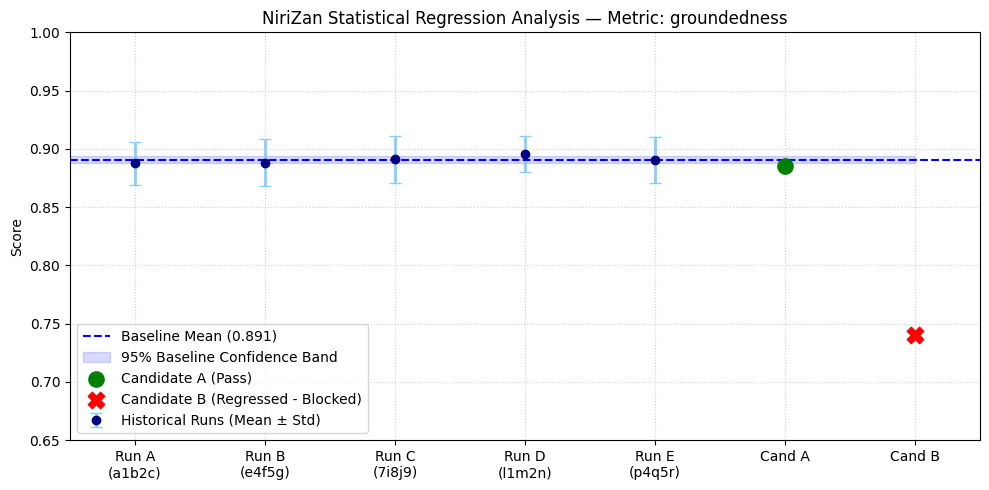

In [8]:
# Extract metric across baseline runs
m_name = "groundedness"
run_labels = [f"Run {chr(65+i)}\n({r.commit_sha[:5]})" for i, r in enumerate(baseline_runs)]
means = [np.mean(r.metrics[m_name].scores) for r in baseline_runs]
stds = [np.std(r.metrics[m_name].scores) for r in baseline_runs]

# Overall historical baseline stats
all_base_scores = [s for r in baseline_runs for s in r.metrics[m_name].scores]
grand_mean = np.mean(all_base_scores)
grand_se = np.std(all_base_scores) / math.sqrt(len(all_base_scores))

# Add candidate runs
cand_pass_mean = 0.885
cand_fail_mean = 0.740

plt.figure(figsize=(10, 5))
plt.errorbar(range(len(means)), means, yerr=stds, fmt='o', color='navy', ecolor='lightskyblue', elinewidth=2, capsize=4, label='Historical Runs (Mean ± Std)')
plt.axhline(grand_mean, color='blue', linestyle='--', label=f'Baseline Mean ({grand_mean:.3f})')
plt.fill_between(range(-1, len(means)+2), grand_mean - 1.96*grand_se, grand_mean + 1.96*grand_se, color='blue', alpha=0.15, label='95% Baseline Confidence Band')

# Plot Candidates
plt.scatter([len(means)], [cand_pass_mean], color='green', s=120, zorder=5, label='Candidate A (Pass)')
plt.scatter([len(means)+1], [cand_fail_mean], color='red', marker='X', s=140, zorder=5, label='Candidate B (Regressed - Blocked)')

plt.xticks(list(range(len(means))) + [len(means), len(means)+1], run_labels + ['Cand A', 'Cand B'])
plt.xlim(-0.5, len(means)+1.5)
plt.ylim(0.65, 1.0)
plt.title(f"NiriZan Statistical Regression Analysis — Metric: {m_name}")
plt.ylabel("Score")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

## Section 9 — Production Extraction Plan

Having mathematically validated the regression algorithms and gate logic, we map the notebook prototype components directly to production source modules in `src/nirizan/`:

| Notebook Prototype | Production Source Module | Responsibility |
| :--- | :--- | :--- |
| `BaselineComparator` | `src/nirizan/regression/comparator.py` | Calculates $z$-scores, deltas, and standard error across baseline and candidate metrics. |
| `eval_z_score`, `eval_welch_t_test` | `src/nirizan/regression/statistics.py` | Low-level statistical distribution helpers, Welch's t-test, and confidence intervals. |
| `MetricRegressionVerdict`, `GateVerdict` | `src/nirizan/gate/verdict.py` | Immutable Pydantic data contracts for regression & release verdicts. |
| `DeploymentGate` | `src/nirizan/gate/gate.py` | Aggregate threshold evaluation engine emitting deployment signals (`PASS` / `FAIL`). |
| `simulate_ci_pipeline` | `src/nirizan/gate/ci.py` | Deployment-aware CLI entry point for integration into GitHub Actions / CI runners. |